In [5]:
import os
import imgcompare
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
import pandas as pd
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

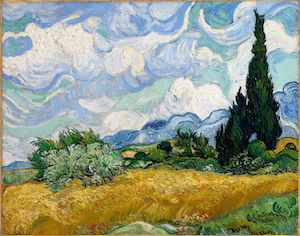

In [6]:
display(REFERENCE_IMAGE)

In [7]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = True

In [8]:
import os
import numpy as np
from time import time

os.makedirs("./img", exist_ok=True)


def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(
            evo.elite,
            evo.reference_image.width,
            evo.reference_image.height,
            scale=IMAGE_SHRINK_SCALE
        )

    if display_output:
        clear_output()
        display(elite)

    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(
            f"./img/van_gogh_intermediate_"
            f"{evo.seed}_{evo.population_size}_{evo.crossover_method}_"
            f"{evo.num_points}_{evo.initialization}_{evo.generation_budget}_"
            f"{time['num-generations']:05d}.png"
        )

def run_algorithm(settings):
    seed, population_size, crossover_method, num_points, initialization, generation_budget = settings
    start = time()

    evo = Evolution(
        num_points,
        REFERENCE_IMAGE,
        population_size=population_size,
        generation_reporter=reporter,
        crossover_method=crossover_method,
        seed=seed,
        initialization=initialization,
        generation_budget=generation_budget,
        num_features_mutation_strength=.25,
        selection_name='tournament_4',
        verbose=verbose_output
    )

    data = evo.run()
    time_spent = time() - start

    print(
        f"Done: run {seed} - pop {population_size} - "
        f"crossover {crossover_method} - num. points {num_points} - "
        f"initialization {initialization} - in {int(time_spent)} seconds"
    )

    return data

## Running a single instance

In [ ]:
%%time
run_algorithm((0, 100, "SPLIT_POS_COLOR", 100, "RANDOM", 500))

## Running a sweep of settings

In [9]:
%%time
# CHANGE TEST CASE HERE!
TEST_CASE = 3   # 1 (Baseline vs Split (Uniform)), 2 (Baseline vs Split (Uniform) vs Split (One Point), or 3 (Baseline vs Split (Uniform) vs No Split (Uniform)

generation_budget = 500

case_methods = {
    1: (
        "ONE_POINT",          # Baseline
        "SPLIT_POS_COLOR",   # Split: position one-point, color uniform
    ),
    2: (
        "ONE_POINT",                  # Baseline
        "SPLIT_POS_COLOR",           # Split: position one-point, color uniform
        "SPLIT_POS_COLOR_ONE_POINT", # Split: position one-point, color one-point
    ),
    3: (
        "ONE_POINT",        # Baseline
        "UNIVARIATE",      # No split, uniform crossover over full genotype
        "SPLIT_POS_COLOR", # Split: position one-point, color uniform
    ),
}

data = []

for seed in range(5):
    for population_size in (100,):
        for initialization in ("RANDOM",):
            for num_points in (100,):

                for crossover_method in case_methods[TEST_CASE]:
                    data.extend(
                        run_algorithm(
                            (
                                seed,
                                population_size,
                                crossover_method,
                                num_points,
                                initialization,
                                generation_budget,
                            )
                        )
                    )

df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)

df.head()

generation: 1 best fitness: 134707 avg. fitness: 143610.45
generation: 2 best fitness: 134273 avg. fitness: 139705.69
generation: 3 best fitness: 131336 avg. fitness: 136312.15
generation: 4 best fitness: 127039 avg. fitness: 134125.79
generation: 5 best fitness: 127039 avg. fitness: 131832.41
generation: 6 best fitness: 123294 avg. fitness: 129270.83
generation: 7 best fitness: 123294 avg. fitness: 127130.28
generation: 8 best fitness: 119067 avg. fitness: 125220.76
generation: 9 best fitness: 118781 avg. fitness: 123393.09
generation: 10 best fitness: 117737 avg. fitness: 121603.97
generation: 11 best fitness: 111216 avg. fitness: 119460.74
generation: 12 best fitness: 111130 avg. fitness: 117245.38
generation: 13 best fitness: 109959 avg. fitness: 114954.43
generation: 14 best fitness: 109789 avg. fitness: 112285.59
generation: 15 best fitness: 109710 avg. fitness: 110793.16
generation: 16 best fitness: 108645 avg. fitness: 110036.45
generation: 17 best fitness: 106170 avg. fitness:

,num-generations,num-evaluations,time-elapsed,best-fitness,crossover-method,population-size,num-points,initialization,seed
0,1,200,0.0,134707,ONE_POINT,100,100,RANDOM,0
1,2,300,0.0,134273,ONE_POINT,100,100,RANDOM,0
2,3,400,0.0,131336,ONE_POINT,100,100,RANDOM,0
3,4,500,1.0,127039,ONE_POINT,100,100,RANDOM,0
4,5,600,1.0,127039,ONE_POINT,100,100,RANDOM,0


## Evaluating the results

In [10]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)

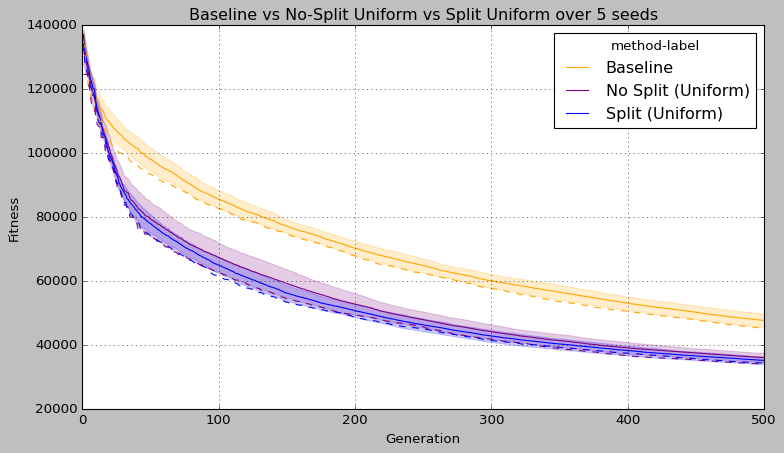

,seed,method-label,best-fitness,time-elapsed
499,0,Baseline,45635,82.0
999,0,No Split (Uniform),36057,78.0
1499,0,Split (Uniform),34857,78.0
1999,1,Baseline,45193,81.0
2499,1,No Split (Uniform),36168,78.0
2999,1,Split (Uniform),34679,78.0
3499,2,Baseline,48710,80.0
3999,2,No Split (Uniform),36171,79.0
4499,2,Split (Uniform),34840,78.0
4999,3,Baseline,48757,78.0


,mean,std,min,max,count
method-label,,,,,
Split (Uniform),35187.4,1195.081713,34277,37284,5
No Split (Uniform),36084.4,1398.810673,34038,37988,5
Baseline,47672.2,2137.797628,45193,50066,5


In [11]:
# Plotting code for selected tEST_CASE
method_labels = {
    "ONE_POINT": "Baseline",
    "UNIVARIATE": "No Split (Uniform)",
    "SPLIT_POS_COLOR": "Split (Uniform)",
    "SPLIT_POS_COLOR_ONE_POINT": "Split (One Point)",
}

method_palette = {
    "Baseline": "orange",
    "No Split (Uniform)": "purple",
    "Split (Uniform)": "blue",
    "Split (One Point)": "green",
}

df["method-label"] = df["crossover-method"].replace(method_labels)

plt.figure(figsize=(11, 6))


# Solid lines: mean best-fitness over seeds
sns.lineplot(
    data=df,
    x="num-generations",
    y="best-fitness",
    hue="method-label",
    estimator="mean",
    errorbar="sd",
    palette=method_palette
)


# Dashed lines: best fitness at each generation across seeds
best_per_generation = (
    df.groupby(["method-label", "num-generations"], as_index=False)["best-fitness"]
    .min()
)

sns.lineplot(
    data=best_per_generation,
    x="num-generations",
    y="best-fitness",
    hue="method-label",
    estimator=None,
    palette=method_palette,
    linestyle="--",
    legend=False
)

case_titles = {
    1: "Baseline vs Split Uniform Crossover over 5 seeds",
    2: "Baseline vs Split Uniform vs Split One-Point over 5 seeds",
    3: "Baseline vs No-Split Uniform vs Split Uniform over 5 seeds",
}

plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.title(case_titles[TEST_CASE])
plt.grid(True)
plt.show()



# Create final_df: final generation result for each run
final_df = df.loc[
    df.groupby(
        ["seed", "population-size", "crossover-method", "num-points", "initialization"]
    )["num-generations"].idxmax()
].copy()

final_df["method-label"] = final_df["crossover-method"].replace(method_labels)



# Table: final best fitness per run
display(final_df[
    [
        "seed",
        "method-label",
        "best-fitness",
        "time-elapsed",
    ]
].sort_values(["seed", "method-label"]))



# Summary table: average final performance per method
summary = final_df.groupby("method-label")["best-fitness"].agg(
    ["mean", "std", "min", "max", "count"]
).sort_values("mean")

display(summary)

In [12]:
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, population_size, crossover_method, num_points, generation_budget = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(50, generation_budget + 50, 50)
    
    img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{population_size}_{crossover_method}_{num_points}_RANDOM_{generation_budget}_{i:05d}.png")) for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

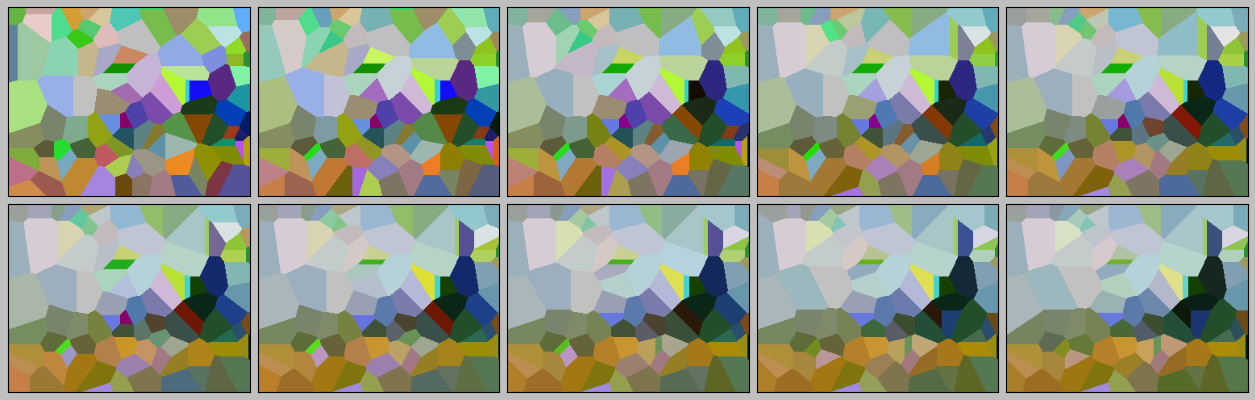

In [13]:
show_progress_over_time((0, 100, 'SPLIT_POS_COLOR', 100, 500), grid=(2,5))

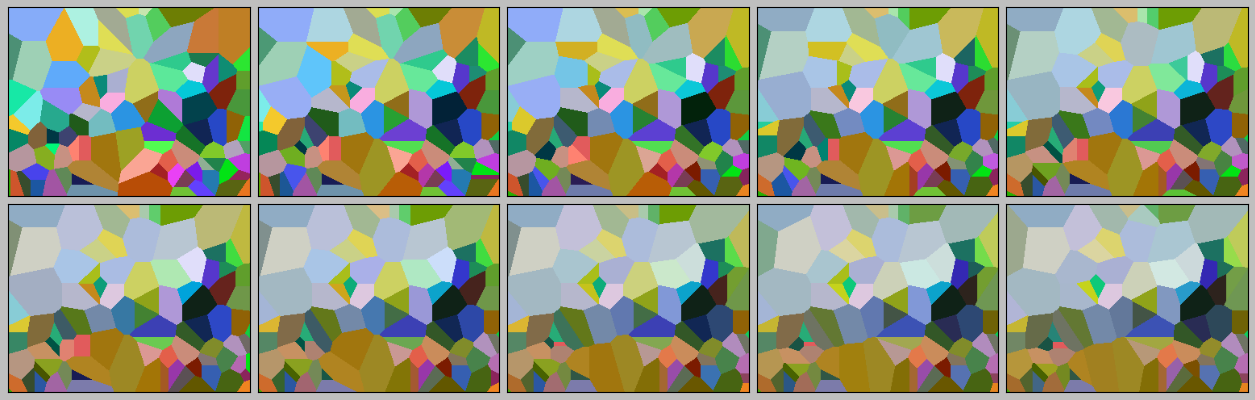

In [14]:
show_progress_over_time((0, 100, "SPLIT_POS_COLOR_ONE_POINT", 100, 500),
    grid=(2, 5)
)

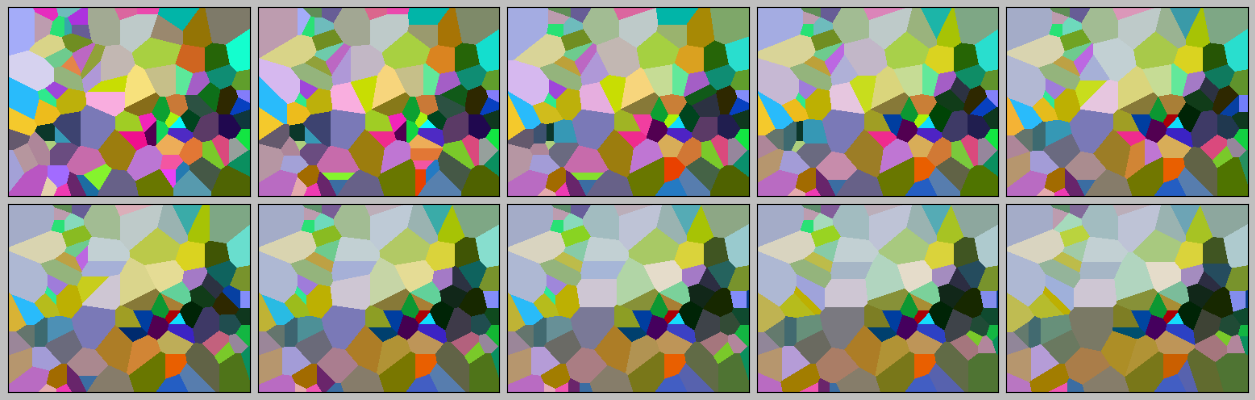

In [15]:
show_progress_over_time((0, 100, "ONE_POINT", 100, 500),
    grid=(2, 5)
)

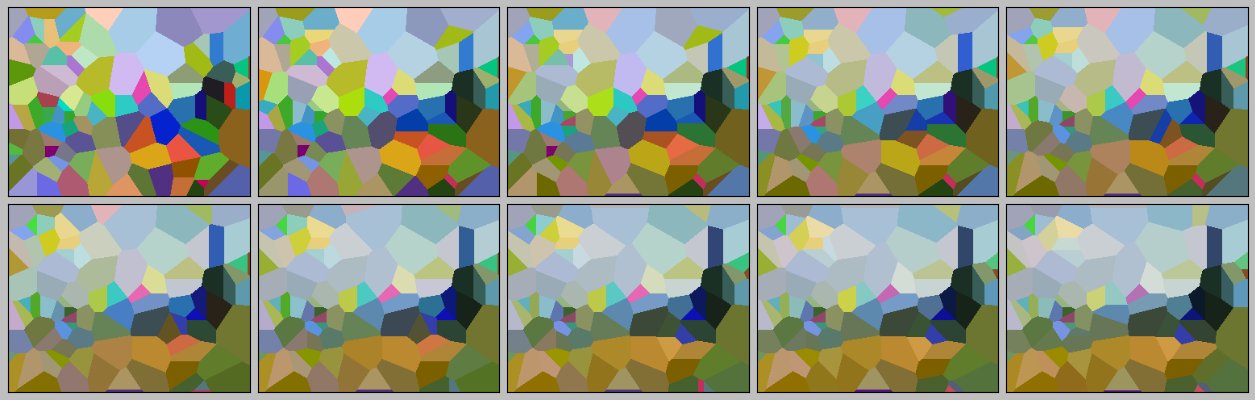

In [16]:
show_progress_over_time((0, 100, "UNIVARIATE", 100, 500),
    grid=(2, 5)
)